In [1]:

import numpy as np
import matplotlib.pyplot as plt
import cv2

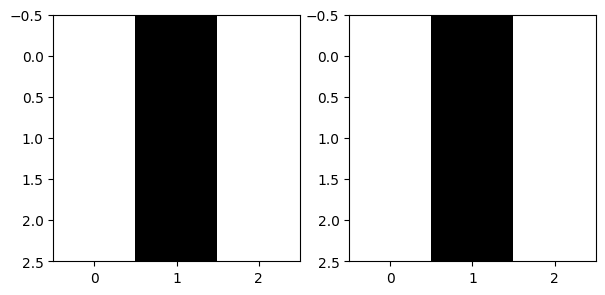

In [ ]:
# convoltion kernel
org_kernel = np.array([[1,2,3],[4,5,6],[7,8,9]])
org_kernel = ((org_kernel / 9)*255)
con = np.flipud(np.fliplr(org_kernel))

fig, axe = plt.subplots(1,2, figsize=(7,7))

axe[0].imshow(org_kernel, cmap='gray')

axe[1].imshow(con, cmap='gray')


In [ ]:
# convolution on image 
kernel = org_kernel
img = np.zeros((5,5))
img[2,2] = 1
output = np.zeros((3,3))

rows = output.shape[0]
cols = output.shape[1]

for row in range(rows):
    for col in range(cols):
        reg = img[row:row + 3, col:col + 3]
        result = np.sum(reg * kernel)
        output[row,col] = result
        
fig, axe = plt.subplots(1,3, figsize = (7,10))

axe[0].imshow(img, cmap='gray')
axe[0].set_title('original image')

axe[1].imshow(kernel, cmap='gray')
axe[1].set_title('kernel image')

axe[2].imshow(output, cmap='gray')
axe[2].set_title('output image')

for i in range(3):
    axe[i].axis('off')

array([[ 14,  14,  14, ..., 241, 242, 236],
       [ 14,  14,  14, ..., 240, 240, 236],
       [ 14,  14,  14, ..., 239, 238, 236],
       ...,
       [101, 101, 101, ..., 182, 181, 183],
       [ 90,  94,  95, ..., 181, 180, 186],
       [ 73,  81,  84, ..., 182, 181, 190]], shape=(379, 510), dtype=uint8)

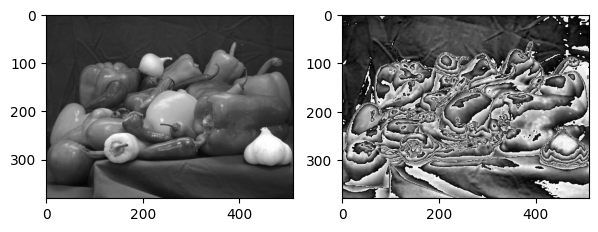

In [28]:
# convolotion through the image
kernel = np.array([[1,0,1],[1,0,1],[1,0,1]])
kernel = np.flipud(np.fliplr(kernel))
img = cv2.imread('images/peppers.jpg',0)

out_img = np.zeros((img.shape[0] - 2, img.shape[1] - 2), dtype=('uint8'))

rows = out_img.shape[0]
cols = out_img.shape[1]

for row in range(rows):
    for col in range(cols):
        reg = img[row:row + 3, col:col + 3]
        res = np.sum(reg * kernel)
        out_img[row,col] = res

fig, axe = plt.subplots(1,2, figsize=(7,7))
axe[0].imshow(img, cmap='gray')
axe[1].imshow(out_img, cmap='gray')

out_img

Text(0.5, 1.0, 'convolution')

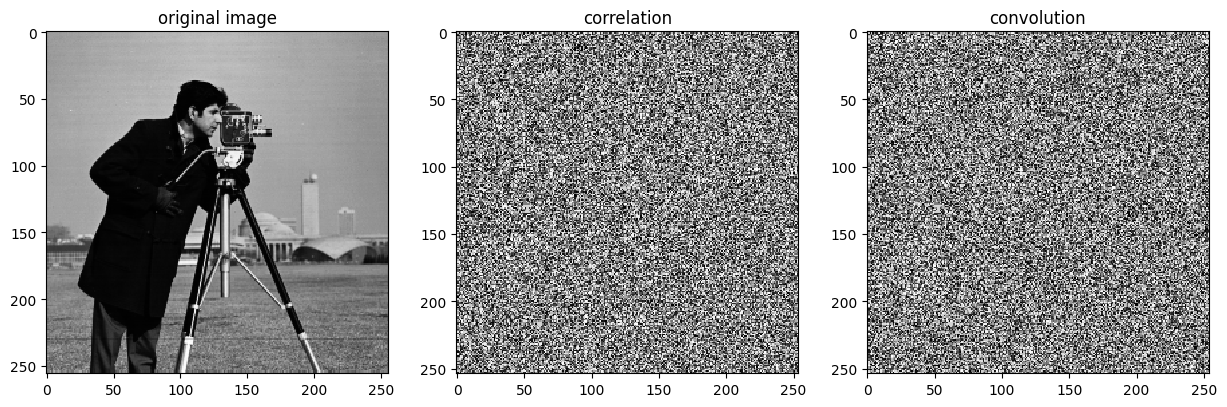

In [17]:
# convolution and correlation 
img = cv2.imread('images/cameraman.tif', cv2.IMREAD_GRAYSCALE)

kernel = np.array([[1,2,3],
                   [4,5,6],
                   [7,8,9]
                   ])

kernel = ((kernel / 9) * 255)

cor_kernel = kernel
con_kernel = np.flipud(np.fliplr(kernel))

cor_out_img = np.zeros((img.shape[0] - 2, img.shape[1] - 2), dtype='uint8')
con_out_img = np.zeros((img.shape[0] - 2, img.shape[1] - 2), dtype='uint8')

rows = con_out_img.shape[0]
cols = con_out_img.shape[1]

for row in range(rows):
    for col in range(cols):
        reg = img[row:row + 3, col : col + 3]
        cor_res = np.sum(reg * cor_kernel)
        con_res = np.sum(reg * con_kernel)

        cor_out_img[row,col] = cor_res
        con_out_img[row, col] = con_res


fig, axe = plt.subplots(1,3, figsize=(15,5))

axe[0].imshow(img, cmap='gray', interpolation='nearest')
axe[0].set_title("original image")

axe[1].imshow(cor_out_img, cmap='gray', interpolation='nearest')
axe[1].set_title("correlation")

axe[2].imshow(con_out_img, cmap='gray', interpolation='nearest')
axe[2].set_title("convolution")